In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import os

In [2]:
X_train_pad = np.load(
    "processed_data/X_train.npy"
)

X_val_pad = np.load(
    "processed_data/X_val.npy"
)

X_test_pad = np.load(
    "processed_data/X_test.npy"
)

y_train = np.load(
    "processed_data/y_train.npy"
)

y_val = np.load(
    "processed_data/y_val.npy"
)

y_test = np.load(
    "processed_data/y_test.npy"
)

In [3]:
print("Training:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Testing:", X_test_pad.shape)

Training: (34998, 200)
Validation: (7502, 200)
Testing: (7500, 200)


In [4]:
VOCAB_SIZE = 20000

BASE_SEQUENCE_LENGTH = 200

BASE_EMBEDDING_DIM = 128

BASE_HIDDEN_UNITS = 64

BASE_DROPOUT = 0.3

BASE_BATCH_SIZE = 64

BASE_EPOCHS = 10

In [5]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    probabilities = model.predict(
        X_test,
        verbose=0
    ).flatten()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    print("\n", model_name)

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [6]:
#Build Baseline LSTM
def build_baseline_lstm():

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        LSTM(
            64
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            0.3
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [7]:
#Train Baseline LSTM
baseline_lstm = build_baseline_lstm()

baseline_history = baseline_lstm.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5


/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 100ms/step - accuracy: 0.5336 - loss: 0.6857 - val_accuracy: 0.5741 - val_loss: 0.6732
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - accuracy: 0.6662 - loss: 0.6048 - val_accuracy: 0.5088 - val_loss: 0.6976
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - accuracy: 0.6631 - loss: 0.5807 - val_accuracy: 0.8388 - val_loss: 0.3879
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.8903 - loss: 0.2870 - val_accuracy: 0.8731 - val_loss: 0.3201
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - accuracy: 0.9360 - loss: 0.1885 - val_accuracy: 0.8678 - val_loss: 0.3535


In [8]:
#Evaluate Baseline LSTM
baseline_result = evaluate_model(

    baseline_lstm,

    X_test_pad,

    y_test,

    "Baseline LSTM"
)


 Baseline LSTM
Accuracy: 0.8632
Precision: 0.9027
Recall: 0.8141
F1 Score: 0.8561
ROC-AUC: 0.9425


In [9]:
os.makedirs(
    "saved_models",
    exist_ok=True
)

baseline_lstm.save(
    "saved_models/baseline_lstm.keras"
)

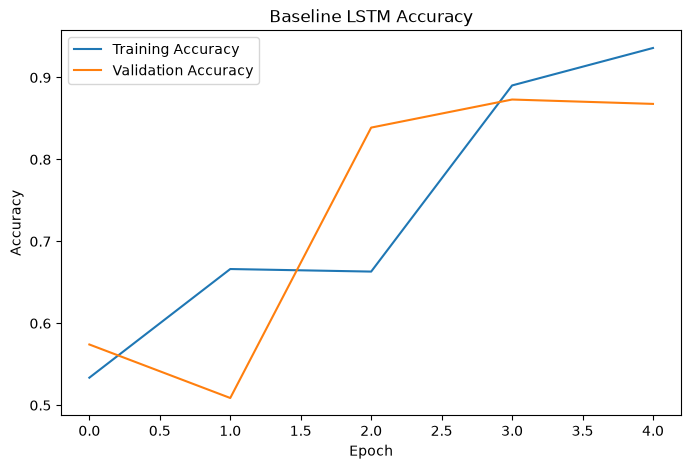

In [10]:
#Plot Baseline Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Baseline LSTM Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [11]:
embedding_results = []

for embedding_dim in [64, 128, 256]:

    print(
        "\nTesting Embedding Dimension:",
        embedding_dim
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=embedding_dim,
            input_length=200
        ),

        LSTM(64),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    val_accuracy = max(
        history.history["val_accuracy"]
    )

    embedding_results.append({

        "Embedding Dimension": embedding_dim,

        "Validation Accuracy": val_accuracy

    })


Testing Embedding Dimension: 64


/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.5145 - loss: 0.6926 - val_accuracy: 0.5487 - val_loss: 0.6841
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step - accuracy: 0.5739 - loss: 0.6671 - val_accuracy: 0.5000 - val_loss: 0.7137
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.6807 - loss: 0.5717 - val_accuracy: 0.8342 - val_loss: 0.3982

Testing Embedding Dimension: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.5428 - loss: 0.6810 - val_accuracy: 0.5660 - val_loss: 0.6587
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.6835 - loss: 0.5839 - val_accuracy: 0.7003 - val_loss: 0.5951
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.8294 - loss: 0.4091 - val_accuracy: 0.8512 - val_loss: 0.3650

Testing Embedding Dimension: 256
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 130s 236ms/step - accuracy: 0.5455 - loss: 0.6815 - val_accuracy: 0.5708 - val_loss: 0.6783
Epoch 2/3
547/547 ━━━━━━

In [12]:
embedding_df = pd.DataFrame(
    embedding_results
)

embedding_df

,Embedding Dimension,Validation Accuracy
0,64,0.834178
1,128,0.851240
2,256,0.867635


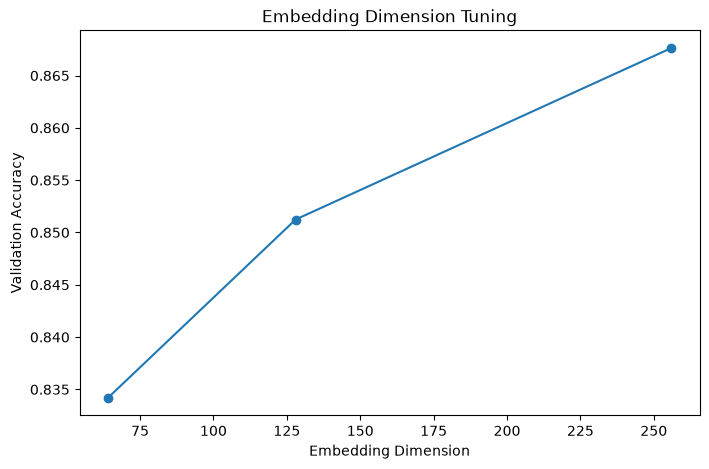

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    embedding_df["Embedding Dimension"],
    embedding_df["Validation Accuracy"],
    marker="o"
)

plt.title(
    "Embedding Dimension Tuning"
)

plt.xlabel(
    "Embedding Dimension"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.show()

In [14]:
hidden_results = []

for units in [32, 64, 128]:

    print(
        "\nTesting Hidden Units:",
        units
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        LSTM(
            units
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    hidden_results.append({

        "Hidden Units": units,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Hidden Units: 32


/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 49s 86ms/step - accuracy: 0.5630 - loss: 0.6751 - val_accuracy: 0.7483 - val_loss: 0.6146
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 45s 83ms/step - accuracy: 0.6384 - loss: 0.6207 - val_accuracy: 0.6120 - val_loss: 0.6236
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - accuracy: 0.7010 - loss: 0.5673 - val_accuracy: 0.8069 - val_loss: 0.4744

Testing Hidden Units: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 101s 181ms/step - accuracy: 0.5203 - loss: 0.6927 - val_accuracy: 0.5492 - val_loss: 0.6788
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 81s 147ms/step - accuracy: 0.5620 - loss: 0.6752 - val_accuracy: 0.6440 - val_loss: 0.6403
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 74s 135ms/step - accuracy: 0.5835 - loss: 0.6573 - val_accuracy: 0.5168 - val_loss: 0.6897

Testing Hidden Units: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 129s 234ms/step - accuracy: 0.5217 - loss: 0.6910 - val_accuracy: 0.5259 - val_loss: 0.6868
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━

In [15]:
hidden_df = pd.DataFrame(
    hidden_results
)

hidden_df

,Hidden Units,Validation Accuracy
0,32,0.806852
1,64,0.643962
2,128,0.685817


In [16]:
#Tune Dropout
dropout_results = []

for dropout_rate in [0.2, 0.3, 0.5]:

    print(
        "\nTesting Dropout:",
        dropout_rate
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        LSTM(64),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            dropout_rate
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    dropout_results.append({

        "Dropout": dropout_rate,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Dropout: 0.2


/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 75s 135ms/step - accuracy: 0.5256 - loss: 0.6874 - val_accuracy: 0.5156 - val_loss: 0.6904
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 75s 137ms/step - accuracy: 0.6274 - loss: 0.6373 - val_accuracy: 0.6901 - val_loss: 0.5966
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 74s 136ms/step - accuracy: 0.7015 - loss: 0.5763 - val_accuracy: 0.7022 - val_loss: 0.5761

Testing Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 76s 137ms/step - accuracy: 0.5311 - loss: 0.6894 - val_accuracy: 0.5676 - val_loss: 0.6694
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 75s 138ms/step - accuracy: 0.5265 - loss: 0.6882 - val_accuracy: 0.5424 - val_loss: 0.6872
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 73s 133ms/step - accuracy: 0.7274 - loss: 0.5207 - val_accuracy: 0.8590 - val_loss: 0.3420

Testing Dropout: 0.5
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 76s 135ms/step - accuracy: 0.5457 - loss: 0.6786 - val_accuracy: 0.6136 - val_loss: 0.6268
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 75s 137

In [17]:
#Display Dropout Results
dropout_df = pd.DataFrame(
    dropout_results
)

dropout_df

,Dropout,Validation Accuracy
0,0.2,0.702213
1,0.3,0.858971
2,0.5,0.803386


In [18]:
#Tune Recurrent Dropout
recurrent_results = []

for recurrent_dropout in [0.0, 0.2, 0.3]:

    print(
        "\nTesting Recurrent Dropout:",
        recurrent_dropout
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        LSTM(
            64,
            dropout=0.3,
            recurrent_dropout=recurrent_dropout
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    recurrent_results.append({

        "Recurrent Dropout":
            recurrent_dropout,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Recurrent Dropout: 0.0


/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 78s 140ms/step - accuracy: 0.5691 - loss: 0.6793 - val_accuracy: 0.5901 - val_loss: 0.6990
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 77s 140ms/step - accuracy: 0.5524 - loss: 0.6792 - val_accuracy: 0.6838 - val_loss: 0.6200
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 78s 142ms/step - accuracy: 0.6686 - loss: 0.5953 - val_accuracy: 0.7823 - val_loss: 0.4745

Testing Recurrent Dropout: 0.2
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 97s 173ms/step - accuracy: 0.6275 - loss: 0.6479 - val_accuracy: 0.6861 - val_loss: 0.6118
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 95s 173ms/step - accuracy: 0.6846 - loss: 0.6046 - val_accuracy: 0.7361 - val_loss: 0.5661
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 403s 739ms/step - accuracy: 0.7012 - loss: 0.5790 - val_accuracy: 0.6152 - val_loss: 0.6387

Testing Recurrent Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 96s 171ms/step - accuracy: 0.5609 - loss: 0.6726 - val_accuracy: 0.6550 - val_loss: 0.6444
Epoch 2/3
547/547 ━━━━━━━

In [19]:
recurrent_df = pd.DataFrame(
    recurrent_results
)

recurrent_df

,Recurrent Dropout,Validation Accuracy
0,0.0,0.782325
1,0.2,0.736070
2,0.3,0.795788


In [20]:
#Try Batch Normalization
batchnorm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    LSTM(
        64,
        dropout=0.3
    ),

    BatchNormalization(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
batchnorm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [22]:
batchnorm_history = batchnorm_model.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 69s 124ms/step - accuracy: 0.5605 - loss: 0.6754 - val_accuracy: 0.5000 - val_loss: 2.1876
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 66s 120ms/step - accuracy: 0.8488 - loss: 0.3515 - val_accuracy: 0.8522 - val_loss: 0.3421
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 67s 122ms/step - accuracy: 0.9157 - loss: 0.2168 - val_accuracy: 0.8399 - val_loss: 0.3835
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 66s 120ms/step - accuracy: 0.9421 - loss: 0.1534 - val_accuracy: 0.8671 - val_loss: 0.3832
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 67s 122ms/step - accuracy: 0.9644 - loss: 0.0995 - val_accuracy: 0.8434 - val_loss: 0.5856


In [23]:
learning_rate_results = []

for lr in [0.001, 0.0005, 0.0001]:

    print(
        "\nTesting Learning Rate:",
        lr
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        LSTM(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = Adam(
        learning_rate=lr
    )

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    learning_rate_results.append({

        "Learning Rate": lr,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Learning Rate: 0.001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 67s 121ms/step - accuracy: 0.5291 - loss: 0.6882 - val_accuracy: 0.5800 - val_loss: 0.6687
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 66s 120ms/step - accuracy: 0.5242 - loss: 0.6901 - val_accuracy: 0.5012 - val_loss: 0.7001
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 66s 121ms/step - accuracy: 0.6534 - loss: 0.5933 - val_accuracy: 0.8600 - val_loss: 0.3501

Testing Learning Rate: 0.0005
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 67s 120ms/step - accuracy: 0.5283 - loss: 0.6893 - val_accuracy: 0.6062 - val_loss: 0.6816
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 67s 123ms/step - accuracy: 0.6506 - loss: 0.6323 - val_accuracy: 0.6274 - val_loss: 0.6471
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 65s 120ms/step - accuracy: 0.6521 - loss: 0.6270 - val_accuracy: 0.7026 - val_loss: 0.6021

Testing Learning Rate: 0.0001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 68s 122ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5305 - val_loss: 0.692

In [24]:
learning_rate_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_df

,Learning Rate,Validation Accuracy
0,0.0010,0.860037
1,0.0005,0.702613
2,0.0001,0.853372


In [25]:
optimizer_results = []

optimizers = {

    "Adam": Adam(
        learning_rate=0.0005
    ),

    "RMSprop": RMSprop(
        learning_rate=0.0005
    )
}


for optimizer_name, optimizer in optimizers.items():

    print(
        "\nTesting Optimizer:",
        optimizer_name
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        LSTM(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    optimizer_results.append({

        "Optimizer": optimizer_name,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Optimizer: Adam


/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 68s 122ms/step - accuracy: 0.5245 - loss: 0.6889 - val_accuracy: 0.6369 - val_loss: 0.6513
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 65s 119ms/step - accuracy: 0.5861 - loss: 0.6617 - val_accuracy: 0.5737 - val_loss: 0.6622
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 67s 122ms/step - accuracy: 0.5869 - loss: 0.6583 - val_accuracy: 0.5868 - val_loss: 0.6538

Testing Optimizer: RMSprop
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 69s 124ms/step - accuracy: 0.5054 - loss: 0.6931 - val_accuracy: 0.5408 - val_loss: 0.6893
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - accuracy: 0.6934 - loss: 0.6017 - val_accuracy: 0.7999 - val_loss: 0.4853
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 61s 111ms/step - accuracy: 0.8100 - loss: 0.4746 - val_accuracy: 0.8416 - val_loss: 0.4085


In [26]:
optimizer_df = pd.DataFrame(
    optimizer_results
)

optimizer_df

,Optimizer,Validation Accuracy
0,Adam,0.636897
1,RMSprop,0.841642


In [27]:
batch_results = []

for batch_size in [32, 64, 128]:

    print(
        "\nTesting Batch Size:",
        batch_size
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        LSTM(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.0005
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=batch_size,

        verbose=1
    )

    batch_results.append({

        "Batch Size": batch_size,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Batch Size: 32


/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 65s 58ms/step - accuracy: 0.5208 - loss: 0.6898 - val_accuracy: 0.5684 - val_loss: 0.6685
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 64s 58ms/step - accuracy: 0.6003 - loss: 0.6386 - val_accuracy: 0.7862 - val_loss: 0.5046
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 64s 59ms/step - accuracy: 0.7954 - loss: 0.4885 - val_accuracy: 0.8222 - val_loss: 0.4408

Testing Batch Size: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 54s 96ms/step - accuracy: 0.5596 - loss: 0.6752 - val_accuracy: 0.5389 - val_loss: 0.6745
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 54s 99ms/step - accuracy: 0.7004 - loss: 0.5936 - val_accuracy: 0.7442 - val_loss: 0.5635
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 54s 98ms/step - accuracy: 0.5796 - loss: 0.6560 - val_accuracy: 0.5768 - val_loss: 0.6826

Testing Batch Size: 128
Epoch 1/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 38s 136ms/step - accuracy: 0.5183 - loss: 0.6909 - val_accuracy: 0.5872 - val_loss: 0.6704
Epoch 2/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 38

In [28]:
batch_df = pd.DataFrame(
    batch_results
)

batch_df

,Batch Size,Validation Accuracy
0,32,0.822181
1,64,0.744202
2,128,0.671021


In [29]:
optimized_lstm = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.2
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
optimized_optimizer = Adam(
    learning_rate=0.0005
)


optimized_lstm.compile(

    optimizer=optimized_optimizer,

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


optimized_lstm.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True
)

In [32]:
learning_rate_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=1,

    min_lr=0.00001
)

In [33]:
optimized_history = optimized_lstm.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)
optimized_history = optimized_lstm.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 76s 136ms/step - accuracy: 0.5275 - loss: 0.6879 - val_accuracy: 0.5216 - val_loss: 0.6855 - learning_rate: 5.0000e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 73s 133ms/step - accuracy: 0.5899 - loss: 0.6655 - val_accuracy: 0.5623 - val_loss: 0.6698 - learning_rate: 5.0000e-04
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 131ms/step - accuracy: 0.6149 - loss: 0.6458 - val_accuracy: 0.6510 - val_loss: 0.6172 - learning_rate: 5.0000e-04
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 71s 131ms/step - accuracy: 0.7429 - loss: 0.5312 - val_accuracy: 0.8079 - val_loss: 0.4762 - learning_rate: 5.0000e-04
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 132ms/step - accuracy: 0.8655 - loss: 0.3514 - val_accuracy: 0.8604 - val_loss: 0.3459 - learning_rate: 5.0000e-04
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 131ms/step - accuracy: 0.9095 - loss: 0.2541 - val_accuracy: 0.8734 - val_loss: 0.3283 - learning_rate: 5.0000e-04
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 13

In [34]:
optimized_lstm.save(
    "saved_models/optimized_lstm.keras"
)

print(
    "Optimized LSTM saved successfully!"
)

Optimized LSTM saved successfully!


In [35]:
optimized_result = evaluate_model(

    optimized_lstm,

    X_test_pad,

    y_test,

    "Optimized LSTM"
)


 Optimized LSTM
Accuracy: 0.8744
Precision: 0.884
Recall: 0.8619
F1 Score: 0.8728
ROC-AUC: 0.9436


In [36]:
comparison = pd.DataFrame([

    baseline_result,

    optimized_result

])

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline LSTM,0.8632,0.9027,0.8141,0.8561,0.9425
1,Optimized LSTM,0.8744,0.8840,0.8619,0.8728,0.9436


In [37]:
accuracy_improvement = (

    optimized_result["Accuracy"]

    -

    baseline_result["Accuracy"]
)

f1_improvement = (

    optimized_result["F1 Score"]

    -

    baseline_result["F1 Score"]
)

roc_auc_improvement = (

    optimized_result["ROC-AUC"]

    -

    baseline_result["ROC-AUC"]
)


print(
    "Accuracy Improvement:",
    round(
        accuracy_improvement,
        4
    )
)

print(
    "F1 Score Improvement:",
    round(
        f1_improvement,
        4
    )
)

print(
    "ROC-AUC Improvement:",
    round(
        roc_auc_improvement,
        4
    )
)

Accuracy Improvement: 0.0112
F1 Score Improvement: 0.0167
ROC-AUC Improvement: 0.0011


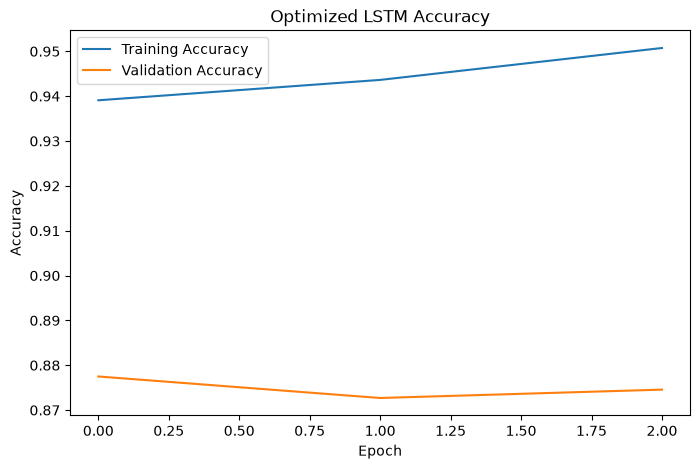

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "accuracy"
    ],

    label="Training Accuracy"
)

plt.plot(

    optimized_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"
)

plt.title(
    "Optimized LSTM Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.show()

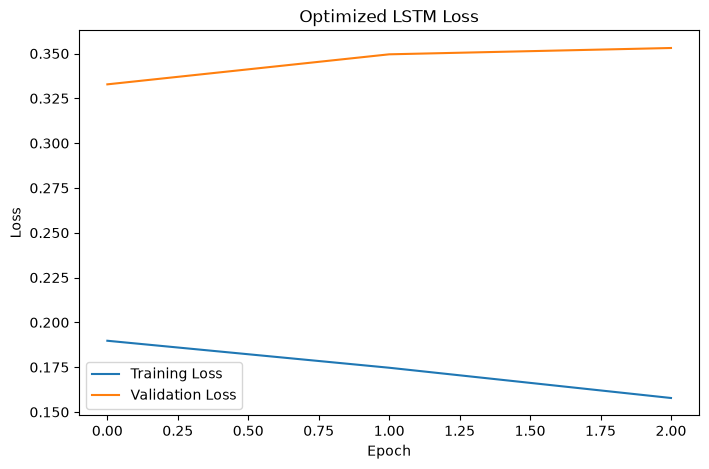

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "loss"
    ],

    label="Training Loss"
)

plt.plot(

    optimized_history.history[
        "val_loss"
    ],

    label="Validation Loss"
)

plt.title(
    "Optimized LSTM Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

In [40]:
embedding_df.to_csv(
    "saved_models/embedding_tuning.csv",
    index=False
)

hidden_df.to_csv(
    "saved_models/hidden_units_tuning.csv",
    index=False
)

dropout_df.to_csv(
    "saved_models/dropout_tuning.csv",
    index=False
)

recurrent_df.to_csv(
    "saved_models/recurrent_dropout_tuning.csv",
    index=False
)

learning_rate_df.to_csv(
    "saved_models/learning_rate_tuning.csv",
    index=False
)

optimizer_df.to_csv(
    "saved_models/optimizer_tuning.csv",
    index=False
)

batch_df.to_csv(
    "saved_models/batch_size_tuning.csv",
    index=False
)

comparison.to_csv(
    "saved_models/baseline_vs_optimized.csv",
    index=False
)

In [41]:
print("=" * 60)

print("PHASE 5 - MODEL IMPROVEMENT COMPLETED")

print("=" * 60)

print("\nBaseline LSTM Accuracy:")

print(
    round(
        baseline_result["Accuracy"],
        4
    )
)

print("\nOptimized LSTM Accuracy:")

print(
    round(
        optimized_result["Accuracy"],
        4
    )
)

print("\nAccuracy Improvement:")

print(
    round(
        accuracy_improvement,
        4
    )
)

print("\nBaseline F1 Score:")

print(
    round(
        baseline_result["F1 Score"],
        4
    )
)

print("\nOptimized F1 Score:")

print(
    round(
        optimized_result["F1 Score"],
        4
    )
)

print("\nF1 Improvement:")

print(
    round(
        f1_improvement,
        4
    )
)

print("\nOptimized Model Saved At:")

print(
    "saved_models/optimized_lstm.keras"
)

PHASE 5 - MODEL IMPROVEMENT COMPLETED

Baseline LSTM Accuracy:
0.8632

Optimized LSTM Accuracy:
0.8744

Accuracy Improvement:
0.0112

Baseline F1 Score:
0.8561

Optimized F1 Score:
0.8728

F1 Improvement:
0.0167

Optimized Model Saved At:
saved_models/optimized_lstm.keras
